# **Cybersecurity Threat Classification using ML - Shayan Rokhva - Data Mining Practice**

### Inits

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier,RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,recall_score,precision_score
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Data

In [ ]:
data=pd.read_csv("/content/drive/MyDrive/CyberSecurity_DATA_.csv")
data.head(5)

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [ ]:
data=data.drop(["session_id","encryption_used"],axis=1)

In [ ]:
data.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [ ]:
data.isnull().sum()

,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0
attack_detected,0


In [ ]:
data.duplicated().sum()

np.int64(0)

# EDA

/tmp/ipython-input-1865189844.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="attack_detected",data=data,palette="Blues")


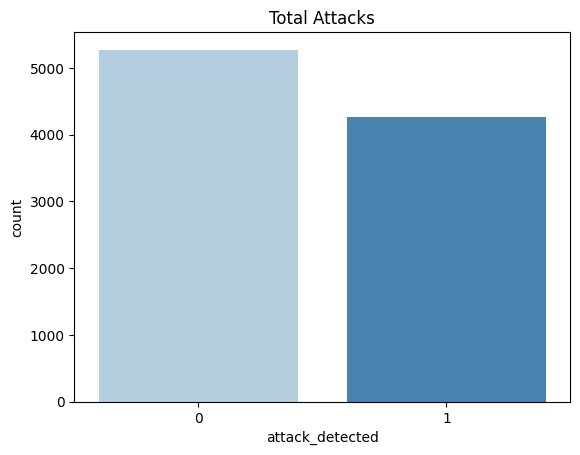

In [ ]:
sns.countplot(x="attack_detected",data=data,palette="Blues")
plt.title("Total Attacks")
plt.show()

In [ ]:
le=LabelEncoder()
data["protocol_type"]=le.fit_transform(data["protocol_type"])
data["browser_type"] = le.fit_transform(data["browser_type"])

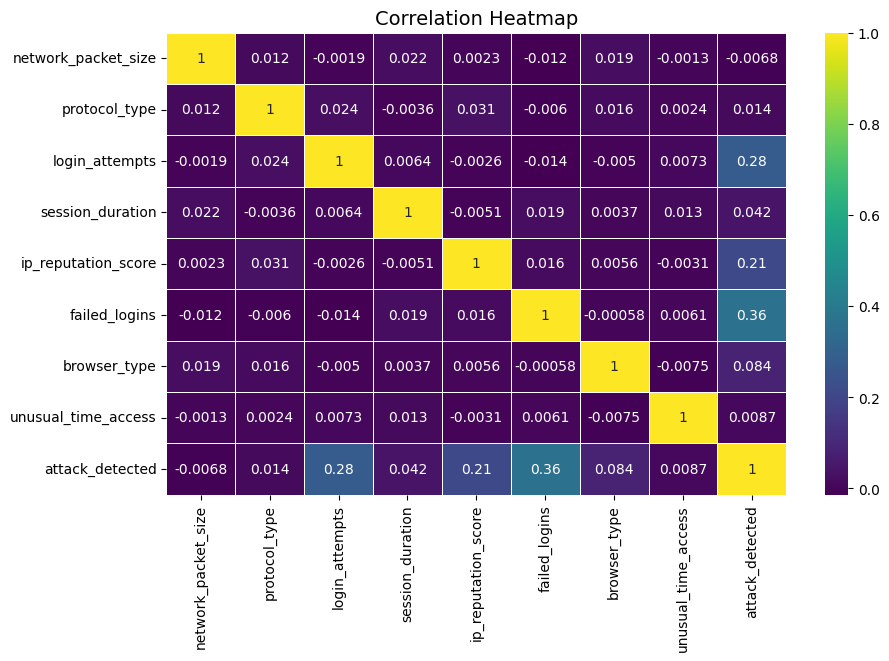

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='viridis', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

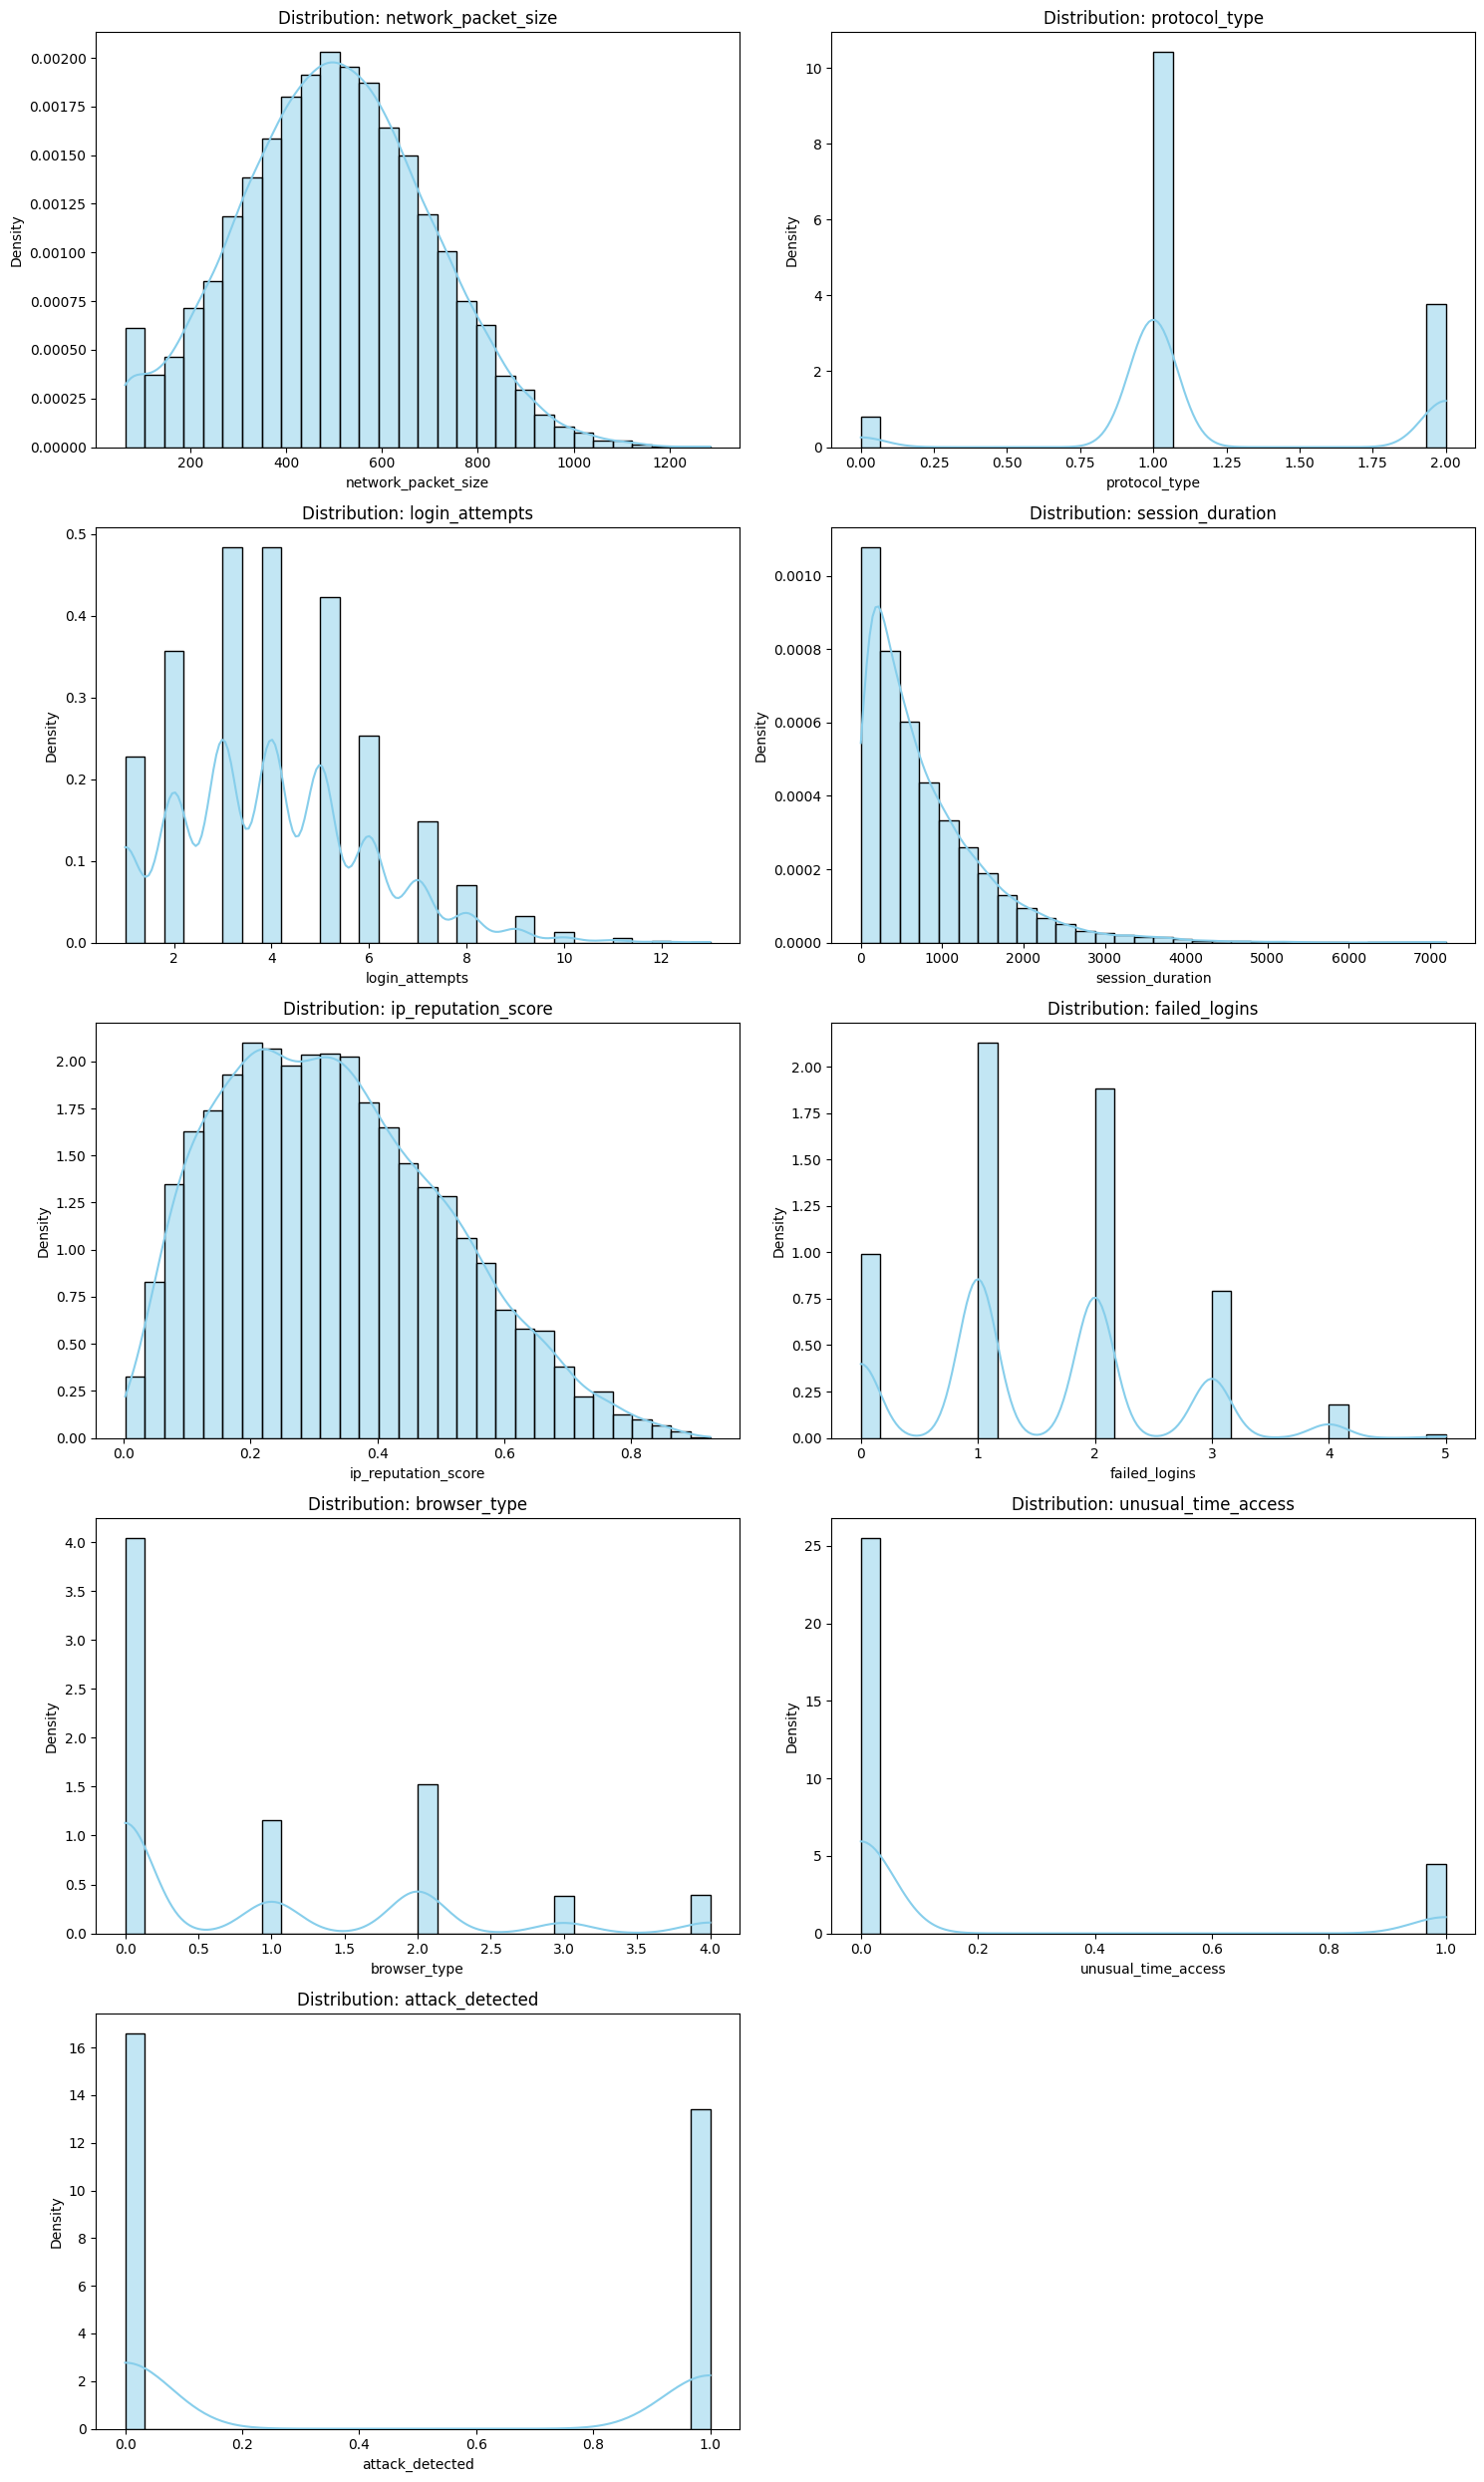

In [ ]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
num_cols = 2
num_rows = (len(numeric_cols) + num_cols - 1) // num_cols
plt.figure(figsize=(15, num_rows * 5))

for i, column in enumerate(numeric_cols, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.histplot(data[column], kde=True, stat='density', color='skyblue', bins=30)
    plt.title(f"Distribution: {column}")
    plt.xlabel(column)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

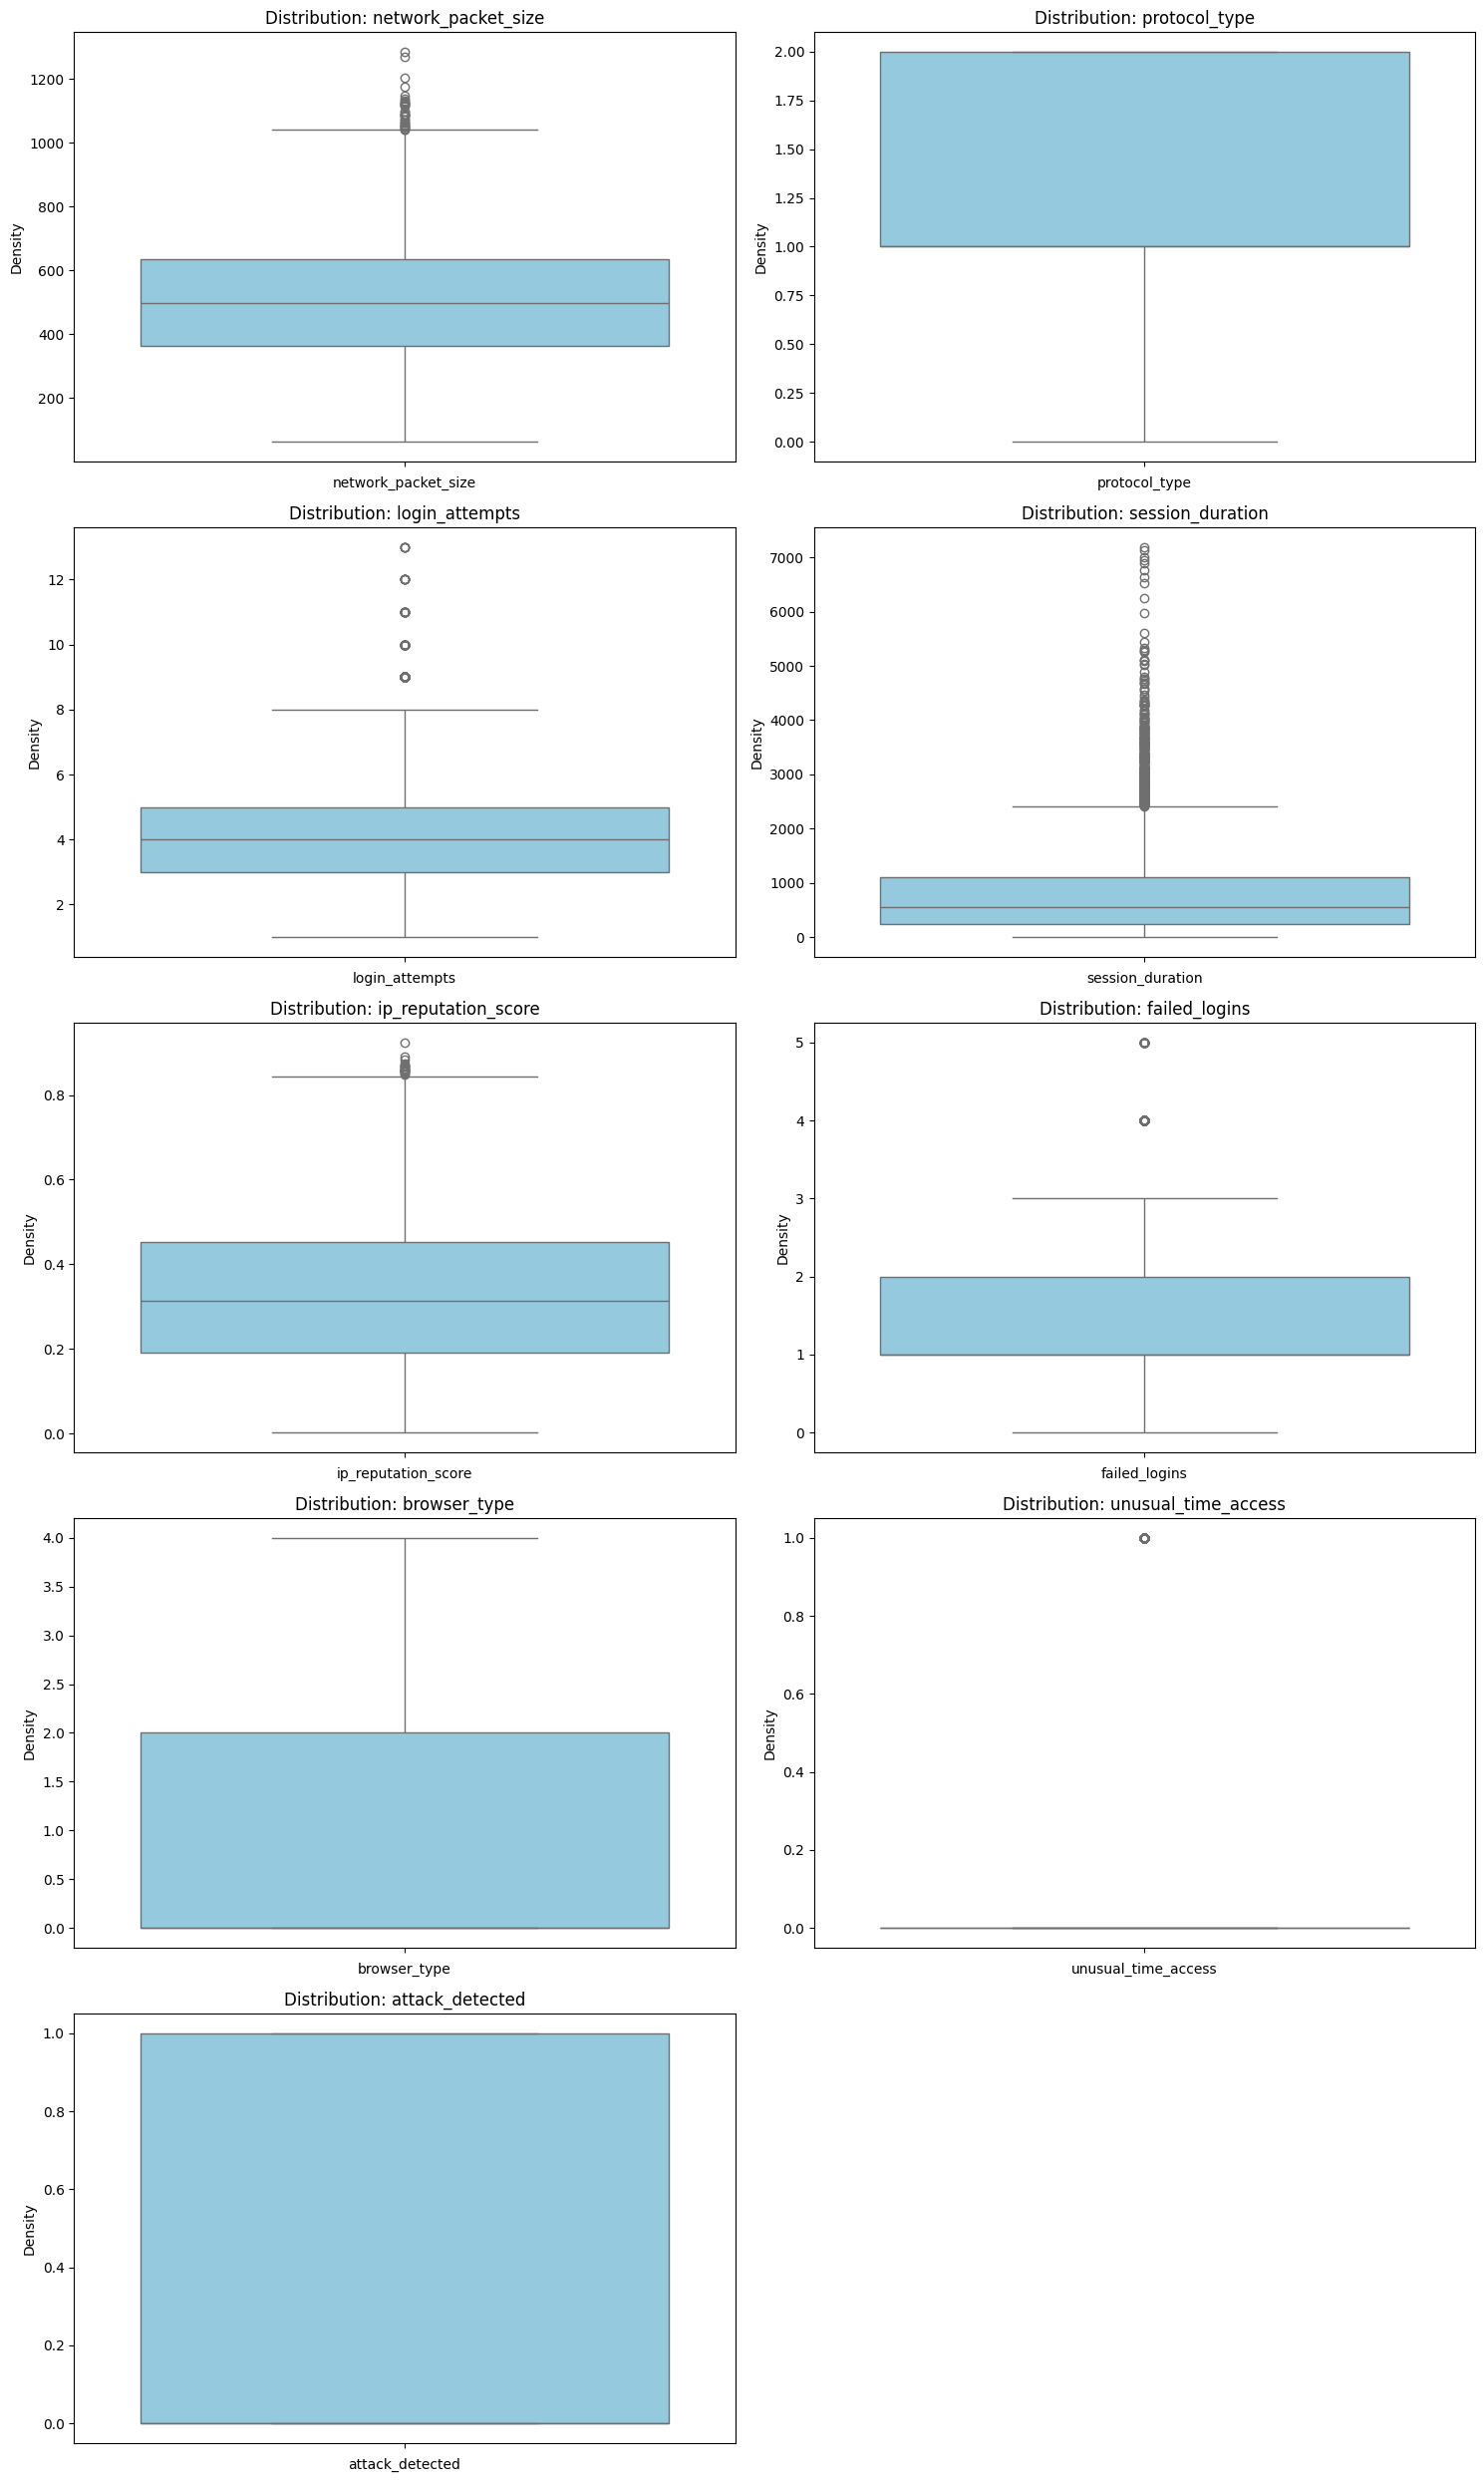

In [ ]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
num_cols = 2
num_rows = (len(numeric_cols) + num_cols - 1) // num_cols
plt.figure(figsize=(15, num_rows * 5))

for i, column in enumerate(numeric_cols, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.boxplot(data[column], color='skyblue')
    plt.title(f"Distribution: {column}")
    plt.xlabel(column)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

# Classifiers (RF, DT, AdaBoost, Logistic Reg, GradientBoosting, NaiveBayes)

In [ ]:
models={
    "Random Forest Classifier":RandomForestClassifier(),
    "Decision Tree Classifier":DecisionTreeClassifier(),
    "Ada Boost Classifier":AdaBoostClassifier(),
    "Logistic Regression":LogisticRegression(),
    "Gradiant Boosting Classifier":GradientBoostingClassifier(),
    "Naive Bayes Classifier":GaussianNB()
}

In [ ]:
x=data.drop(["attack_detected"],axis=1)
y=data["attack_detected"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
ss=StandardScaler()
x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)

In [ ]:
metrics = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall':[]
}
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall=recall_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    metrics['Model'].append(name)
    metrics['Accuracy'].append(acc * 100)
    metrics['Precision'].append(precision * 100)
    metrics['Recall'].append(recall * 100)
    print(f"Model: {name}")
    print(f"Accuracy: {acc*100}")
    print(f"Precision: {precision*100}")
    print(f"F1 Score: {f1*100}")
    print(f"Recall: {recall*100}")
    print("-" * 30)

Model: Random Forest Classifier
Accuracy: 89.51781970649894
Precision: 99.40968122786305
F1 Score: 87.07342295760083
Recall: 77.46090156393744
------------------------------
Model: Decision Tree Classifier
Accuracy: 81.13207547169812
Precision: 78.26086956521739
F1 Score: 79.67479674796748
Recall: 81.1407543698252
------------------------------
Model: Ada Boost Classifier
Accuracy: 86.70859538784067
Precision: 100.0
F1 Score: 82.92945611200861
Recall: 70.83716651333947
------------------------------
Model: Logistic Regression
Accuracy: 74.12997903563941
Precision: 74.63312368972747
F1 Score: 69.76972072513475
Recall: 65.50137994480221
------------------------------
Model: Gradiant Boosting Classifier
Accuracy: 89.39203354297693
Precision: 100.0
F1 Score: 86.82977615825092
Recall: 76.72493100275989
------------------------------
Model: Naive Bayes Classifier
Accuracy: 82.72536687631028
Precision: 84.75798146240989
F1 Score: 79.98056365403305
Recall: 75.71297148114076
-------------------

# Results

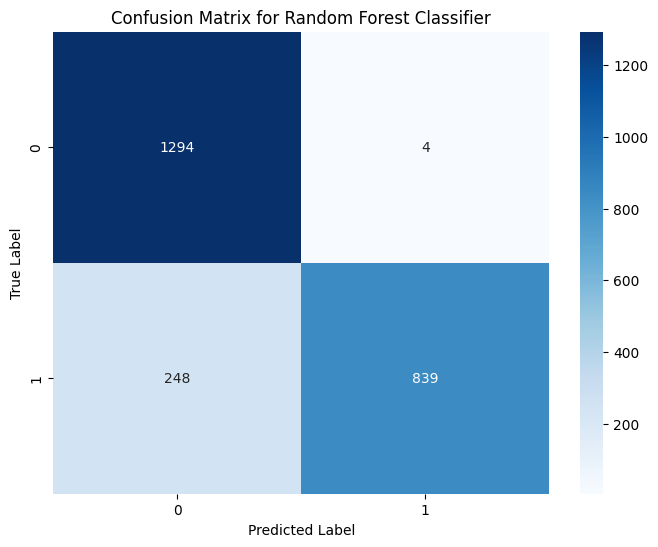

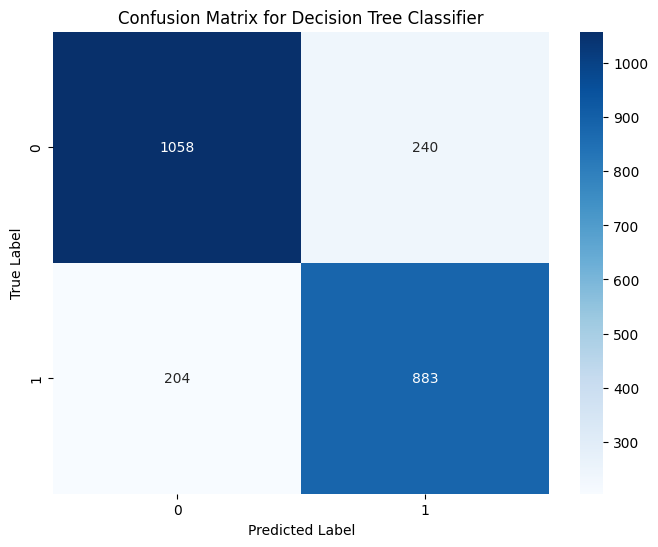

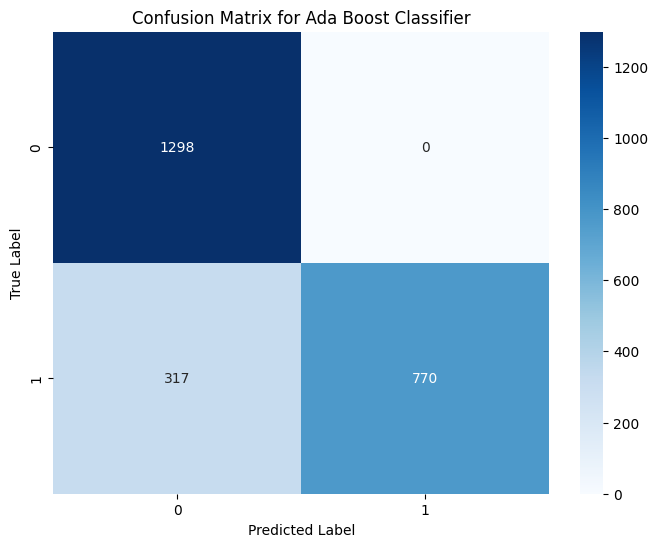

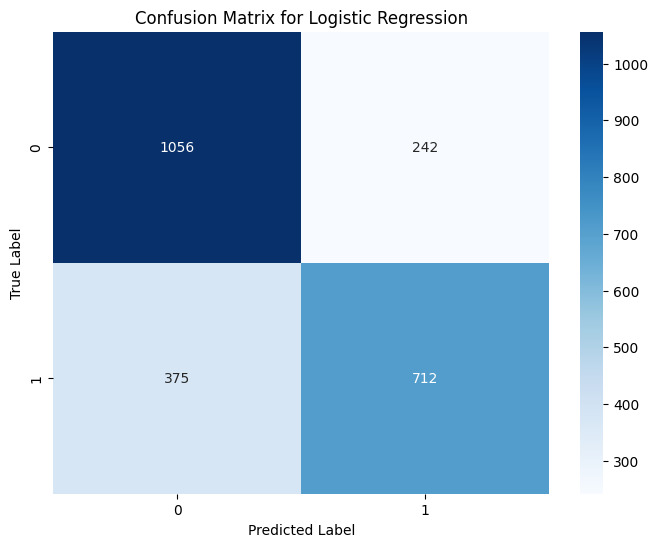

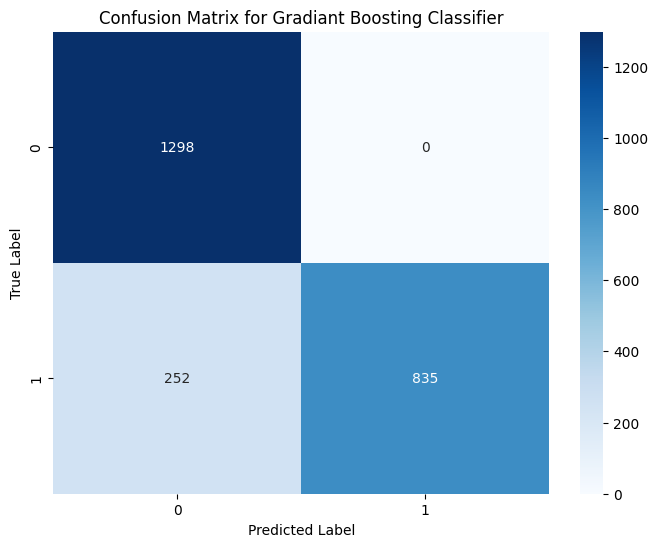

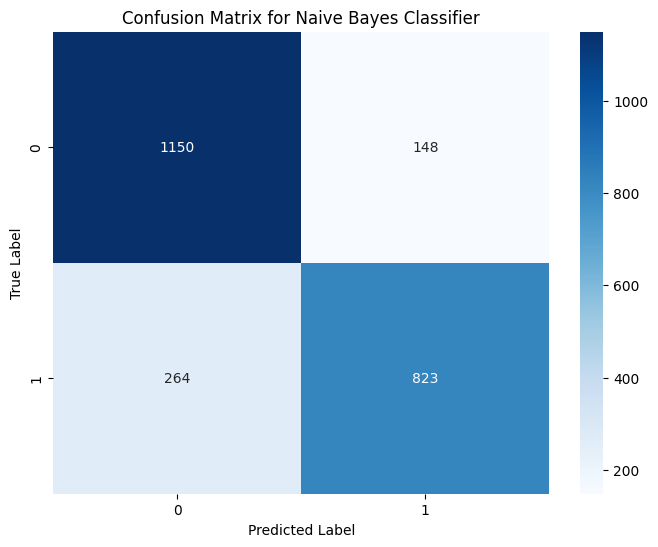

In [ ]:
accuracy_results={}
for name,clf in models.items():
    clf.fit(x_train,y_train)
    y_pred=clf.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    accuracy_results[name]=accuracy
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

<Figure size 1400x700 with 0 Axes>

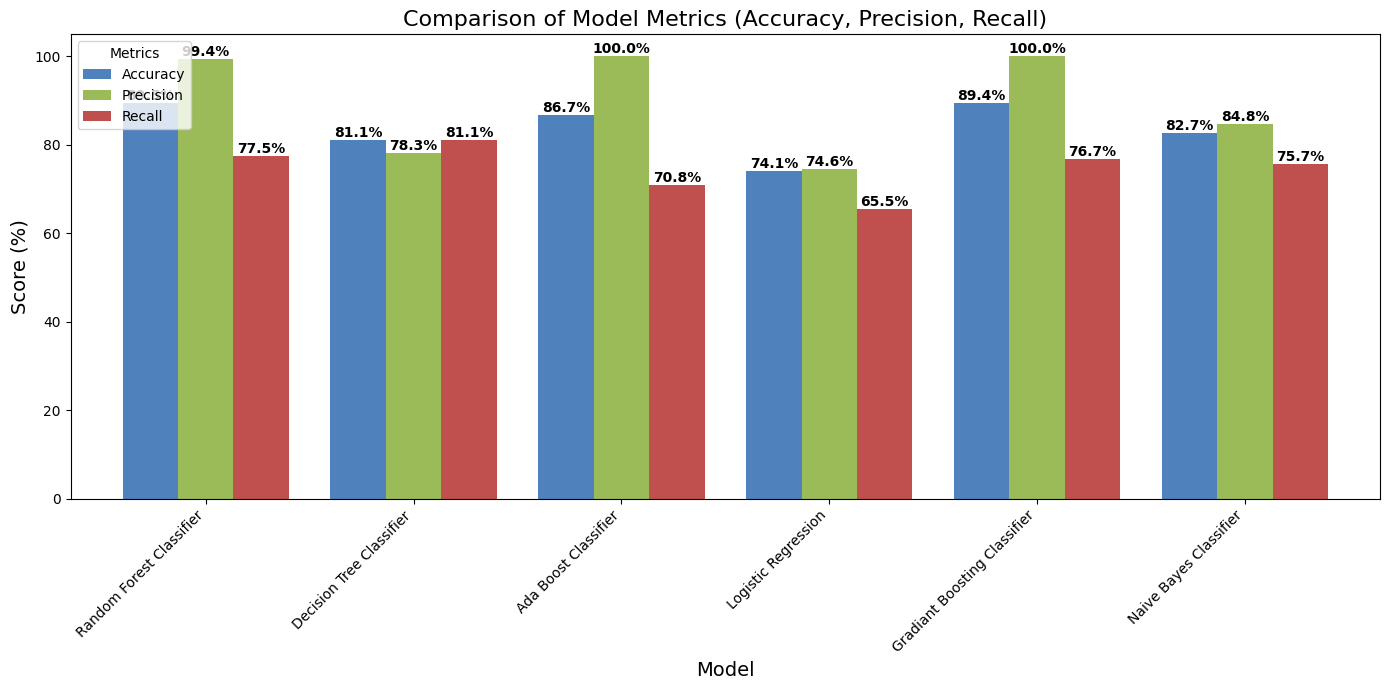

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Create DataFrame (you already have it)
metrics_df = pd.DataFrame(metrics)

# Define colors for each metric
colors = ['#4F81BD', '#9BBB59', '#C0504D']  # Blue, Green, Red

plt.figure(figsize=(14, 7))
ax = metrics_df.set_index('Model').plot(
    kind='bar',
    width=0.8,
    figsize=(14, 7),
    color=colors
)

plt.title('Comparison of Model Metrics (Accuracy, Precision, Recall)', fontsize=16)
plt.ylabel('Score (%)', fontsize=14)
plt.xlabel('Model', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics', loc='upper left')

# Annotate ALL bars with their values
for p in ax.patches:
    value = p.get_height()
    if not pd.isna(value) and value > 0:
        ax.annotate(f'{value:.1f}%',
                    (p.get_x() + p.get_width() / 2, value),
                    ha='center', va='bottom',
                    fontsize=10,
                    color='black',
                    fontweight='bold')

plt.tight_layout()
plt.show()
